## Step 1: Download Tabular Data from GitHub

In [1]:
import requests
import os

BASE_URL = "https://raw.githubusercontent.com/karimabdelmonem/automated-explainable-ai-system/main/data/processed/"
files = [
    "X_train.parquet",
    "X_test.parquet",
    "y_train.parquet",
    "y_test.parquet",
    "data_processed.parquet"
]

print("[*] Downloading data files from GitHub...")
for file_name in files:
    url = BASE_URL + file_name
    print(f"Downloading {file_name}...")
    response = requests.get(url)

    if response.status_code == 200:
        with open(file_name, 'wb') as f:
            f.write(response.content)
    else:
        print(f"[-] Failed to download {file_name}. Status code: {response.status_code}")

print("[✓] All files downloaded successfully.\n")

[*] Downloading data files from GitHub...
[✓] All files downloaded successfully.



## Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Metrics
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve, auc

# Classical ML Models & Search
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Deep Learning Framework (Tabular MLP)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Step 3: Load the Data

In [3]:
print("[*] Loading and preparing data...")
X_train = pd.read_parquet('X_train.parquet')
X_test = pd.read_parquet('X_test.parquet')
y_train = pd.read_parquet('y_train.parquet').squeeze()
y_test = pd.read_parquet('y_test.parquet').squeeze()

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}\n")

[*] Loading and preparing data...
Training Data Shape: (382424, 27)
Testing Data Shape: (38172, 27)



## Step 4: Machine Learning Models with GridSearchCV

In [4]:
# Define the models and parameter grids to search
models_grid = {
    "LightGBM": {
        "model": lgb.LGBMClassifier(random_state=42, verbose=-1),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1]
        }
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5]
        }
    },
    "Random_Forest": {
        "model": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10]
        }
    }
}

In [5]:
probabilities = {}
metrics_results = {}

In [6]:
for name, config in models_grid.items():
    print(f"--- Training & Tuning {name} ---")

    # Perform Grid Search
    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    print(f"[✓] Best Parameters for {name}: {grid_search.best_params_}")

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc_score = roc_auc_score(y_test, y_prob)

    metrics_results[name] = {"Accuracy": acc, "F1-Score": f1, "ROC-AUC": auc_score}
    probabilities[name] = y_prob

    # Save Model as .pkl
    joblib.dump(best_model, f"{name.lower()}_model.pkl")
    print(f"[✓] Saved: {name.lower()}_model.pkl")

--- Training & Tuning LightGBM ---
[✓] Best Parameters for LightGBM: {'learning_rate': 0.1, 'n_estimators': 200}
[✓] Saved: lightgbm_model.pkl
--- Training & Tuning XGBoost ---
[✓] Best Parameters for XGBoost: {'max_depth': 5, 'n_estimators': 100}
[✓] Saved: xgboost_model.pkl
--- Training & Tuning Random_Forest ---
[✓] Best Parameters for Random_Forest: {'max_depth': 10, 'n_estimators': 200}
[✓] Saved: random_forest_model.pkl


## Step 5: Train Deep Learning Tabular Model (MLP)

In [7]:
print("\n--- Training Deep Learning Tabular Model (MLP) ---")

def build_tabular_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

deep_model = build_tabular_model(input_dim=X_train.shape[1])

# Callbacks to monitor performance on validation data
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = deep_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10, # Reduced epochs for faster execution during tuning
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate Deep Learning Model
deep_prob = deep_model.predict(X_test).ravel()
deep_pred = (deep_prob > 0.5).astype(int)

metrics_results["Tabular_DL"] = {
    "Accuracy": accuracy_score(y_test, deep_pred),
    "F1-Score": f1_score(y_test, deep_pred, average='weighted'),
    "ROC-AUC": roc_auc_score(y_test, deep_prob)
}
probabilities["Tabular_DL"] = deep_prob

deep_model.save('tabular_dl_model.keras')
print("\n[✓] Saved tabular deep learning model as tabular_dl_model.keras")


--- Training Deep Learning Tabular Model (MLP) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.8657 - loss: 0.3230 - val_accuracy: 0.9133 - val_loss: 0.1600 - learning_rate: 0.0010
Epoch 2/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8787 - loss: 0.2954 - val_accuracy: 0.9089 - val_loss: 0.1652 - learning_rate: 0.0010
Epoch 3/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8808 - loss: 0.2902 - val_accuracy: 0.9185 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 4/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8821 - loss: 0.2880 - val_accuracy: 0.9160 - val_loss: 0.1525 - learning_rate: 0.0010
Epoch 5/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8833 - loss: 0.2857 - val_accuracy: 0.9180 - val_loss: 0.1441 - learning_rate: 0.0010
Epoch 6/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8847 - loss: 0.2831 - val_accuracy: 0.9177 - val_loss: 0.1406 - learning_rate: 0.0010
Epoch 7/10
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8

## Step 6: Compare Results

In [8]:
df_comparison = pd.DataFrame(metrics_results).T
print("\n--- Final Model Comparison Table ---")
print(df_comparison)


--- Final Model Comparison Table ---
               Accuracy  F1-Score   ROC-AUC
LightGBM       0.883684  0.848719  0.745777
XGBoost        0.881589  0.847701  0.738658
Random_Forest  0.807136  0.817078  0.694552
Tabular_DL     0.870795  0.850754  0.746296


## Step 7: Plot ROC Curves

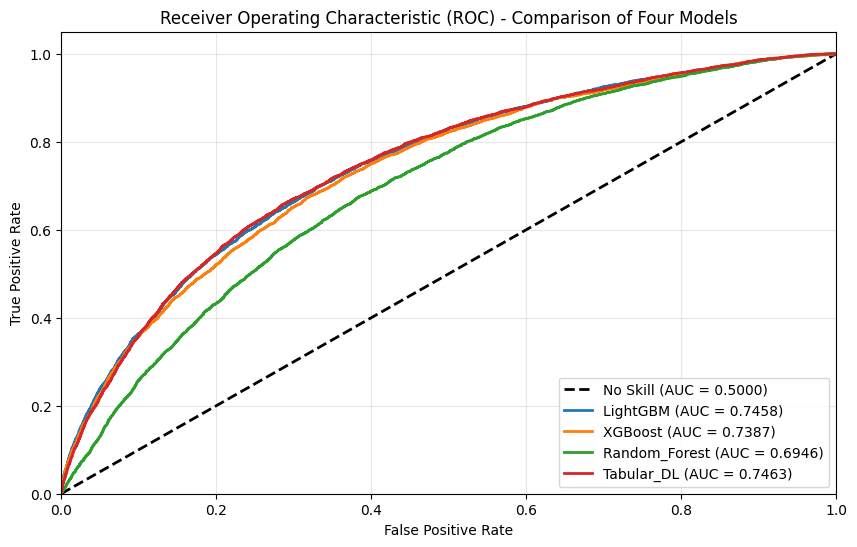


[✓] ROC curve comparison plot saved as models_roc_curves.png


In [9]:
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.5000)')

for name, probs in probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_val:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Comparison of Four Models')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('models_roc_curves.png')
plt.show()
print("\n[✓] ROC curve comparison plot saved as models_roc_curves.png")